# Micronet figure for Muradyan et al. 2026 (Bulletin of the American Meteorological Society, currently in review.)

In [2]:
import xarray as xr 
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
may1 = xr.open_dataset('/nfs/gce/projects/crocus/data/ingested-data/ai-dt/min/crocus_micronet_merged_20250506.v1.nc')
may2 = xr.open_dataset('/nfs/gce/projects/crocus/data/ingested-data/ai-dt/min/crocus_micronet_merged_20250507.v1.nc')
ds = may1.combine_first(may2)

In [3]:
ds

<xarray.Dataset> Size: 4MB
Dimensions:        (site: 11, time: 2880)
Coordinates:
  * time           (time) datetime64[ns] 23kB 2025-05-06 ... 2025-05-07T23:59:00
  * site           (site) <U5 220B 'NU' 'CSU' 'NEIU' ... 'DOWN' 'SHEDD' 'VILLA'
Data variables: (12/20)
    temperature    (site, time) float64 253kB 11.0 11.0 10.92 ... 11.92 11.9
    humidity       (site, time) float64 253kB 81.35 81.3 81.75 ... 55.6 55.44
    pressure       (site, time) float64 253kB 993.4 993.4 993.4 ... 992.2 992.1
    rainfall       (site, time) float64 253kB 123.9 123.9 123.9 ... 230.3 230.3
    dewpoint       (site, time) float64 253kB 7.93 7.921 7.929 ... 3.321 3.261
    wetbulb        (site, time) float64 253kB 9.316 9.311 9.282 ... 7.596 7.561
    ...             ...
    no2            (site, time) float64 253kB nan nan nan ... 0.008 0.008
    co             (site, time) float64 253kB nan nan nan ... 0.034 0.02867
    latitude       (site) float64 88B 42.05 41.72 41.98 ... 41.8 41.87 41.88
    longitude      (site) float64 88B -87.68 -87.61 -87.72 ... -87.61 -87.98
    wsn            (site) <U4 176B 'W099' 'W08E' 'W08D' ... 'W09D' 'W09E' 'W095'
    elevation      (site) float64 88B 21.5 0.0 13.25 0.0 ... -999.0 14.41 8.5
Attributes:
    convention:         CF 1.10
    datalevel:          b1
    history:            created by obrienj at 2025-10-24T15:12:00Z on compute...
    input_datastreams:  Vaisala WXT and Vaisala AQT
    contact:            email questions to obrienj@anl.gov
    comments:           This is an initial evaluation product. Use with Caution.


Combined events (30-min intervals) where temp drops ≥2.0°C AND wind-direction shift is 45–120° (chronological, Central time):
2025-05-06 14:00 CDT: SHEDD  (min drop -3.1°C, max |Δdir| 85°)
2025-05-06 14:30 CDT: NU  (min drop -4.3°C, max |Δdir| 93°)
2025-05-06 15:00 CDT: CCICS  (min drop -2.7°C, max |Δdir| 90°)
2025-05-06 15:30 CDT: BIG  (min drop -2.0°C, max |Δdir| 100°)
2025-05-07 12:00 CDT: UIC  (min drop -2.2°C, max |Δdir| 103°)

Shaded lake-breeze bars (plot extents):
2025-05-06: 2025-05-06 14:00 CDT  →  2025-05-06 16:15 CDT  (duration 0 days 02:15:00)
2025-05-07: 2025-05-07 12:00 CDT  →  2025-05-07 14:15 CDT  (duration 0 days 02:15:00)


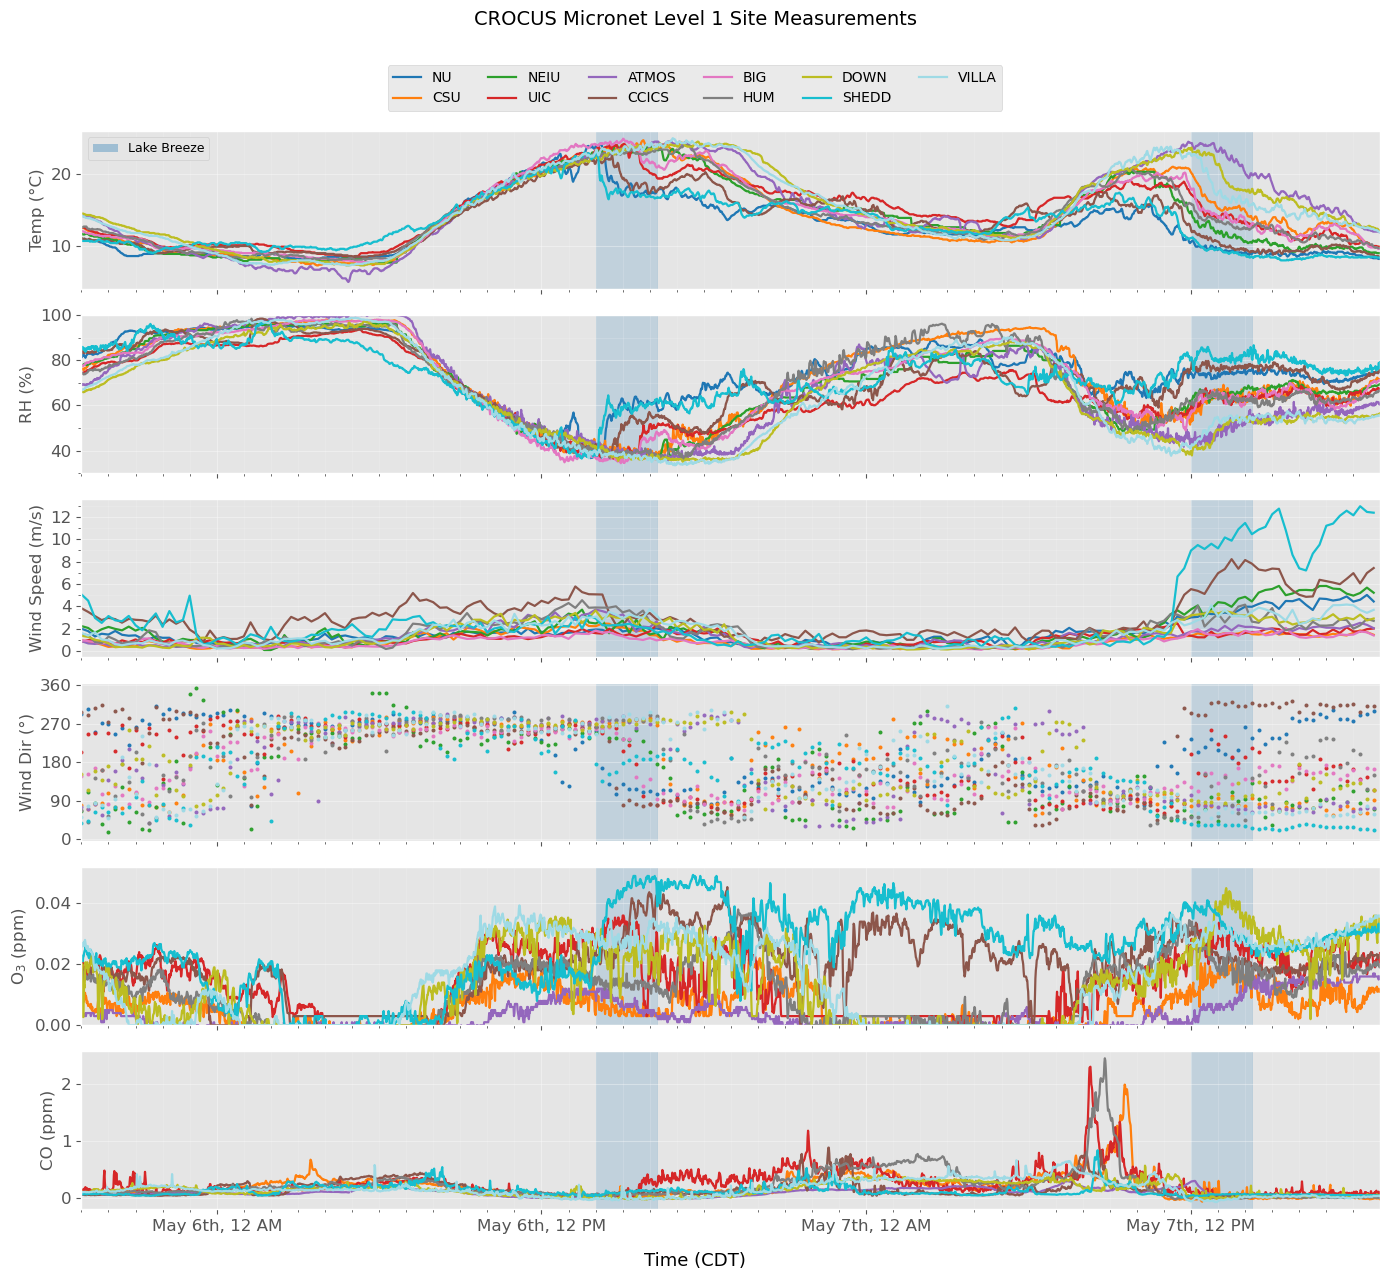

In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator, FuncFormatter
from matplotlib.patches import Patch
from zoneinfo import ZoneInfo  # Python 3.9+
import pandas as pd

plt.style.use('ggplot')

# --- Resampling: ONLY wind gets scalar means (your intervals) ---
spd20  = ds["wind_mean_10s"].resample(time="15min").mean()
wdir15 = ds["wind_dir_10s"].resample(time="15min").mean()

# Temperature, RH, O3, CO at native resolution
temp = ds["temperature"]
rh   = ds["humidity"]
o3   = ds["o3"]
co   = ds["co"]

# --- Build Central time indices (assumes source time is UTC or naive-UTC) ---
def to_central_index(xr_time):
    idx = xr_time.to_index()
    if idx.tz is None:
        idx = idx.tz_localize("UTC")
    return idx.tz_convert("America/Chicago")

t_time    = to_central_index(temp.time)
rh_time   = to_central_index(rh.time)
o3_time   = to_central_index(o3.time)
co_time   = to_central_index(co.time)
spd_time  = to_central_index(spd20.time)
wdir_time = to_central_index(wdir15.time)

# --- Global time bounds (actual data span) ---
idx_list = [
    i for i in [t_time, rh_time, o3_time, co_time, spd_time, wdir_time]
    if len(i) > 0
]
t_min = min(i.min() for i in idx_list)
t_max = max(i.max() for i in idx_list)

# --- Color map for sites (consistent color across panels) ---
sites = list(ds.site.values)
sites = [s.item() if hasattr(s, "item") else s for s in sites]
n_sites = len(sites)

if n_sites <= 20:
    cmap_sites = plt.get_cmap("tab20", n_sites)
    site_color = {s: cmap_sites(i) for i, s in enumerate(sites)}
else:
    cmap_sites = plt.get_cmap("viridis")
    norm_sites = mpl.colors.Normalize(vmin=0, vmax=max(1, n_sites - 1))
    site_color = {s: cmap_sites(norm_sites(i)) for i, s in enumerate(sites)}

# --- Plot: 6 stacked panels, ALL SITES overlaid on each panel ---
# Order: Temp, RH, Wind Speed, Wind Dir, O3, CO
fig, axes = plt.subplots(6, 1, figsize=(14, 12), sharex=True)
axT, axRH, axWS, axWD, axO3, axCO = axes

handles, labels = [], []
for s in ds.site.values:
    s_key = s.item() if hasattr(s, "item") else s
    color = site_color[s_key]

    ln, = axT.plot(t_time,  temp.sel(site=s).to_numpy(), lw=1.6, color=color)
    axRH.plot(rh_time,     rh.sel(site=s).to_numpy(),    lw=1.6, color=color)
    axWS.plot(spd_time,    spd20.sel(site=s).to_numpy(), lw=1.6, color=color)
    axWD.plot(
        wdir_time, wdir15.sel(site=s).to_numpy(),
        linestyle="None", marker=".", markersize=3.8,
        color=color, alpha=0.95
    )
    axO3.plot(o3_time,     o3.sel(site=s).to_numpy(),    lw=1.6, color=color)
    axCO.plot(co_time,     co.sel(site=s).to_numpy(),    lw=1.6, color=color)

    handles.append(ln)
    labels.append(str(s_key))

# Exact bounds + no padding
for ax in axes:
    ax.set_xlim(t_min, t_max)
    ax.margins(x=0)

# ---------- Major ticks ONLY at 12 AM and 12 PM (local), minors hourly ----------
tz_central = ZoneInfo("America/Chicago")
major_loc = mdates.HourLocator(byhour=[0, 12], tz=tz_central)   # labeled
minor_loc = mdates.HourLocator(interval=1, tz=tz_central)       # unlabeled grid

# ---------- Formatter: CDT only (no UTC) ----------
def _ordinal(n: int) -> str:
    if 10 <= n % 100 <= 13:
        suffix = "th"
    else:
        suffix = {1: "st", 2: "nd", 3: "rd"}.get(n % 10, "th")
    return f"{n}{suffix}"

def cdt_formatter(x, pos):
    dt_loc = mdates.num2date(x, tz=tz_central)
    mon    = dt_loc.strftime("%b")
    day    = _ordinal(dt_loc.day)
    hr12   = (dt_loc.hour % 12) or 12
    ampm   = "AM" if dt_loc.hour < 12 else "PM"
    return f"{mon} {day}, {hr12} {ampm}"

fmt_major = FuncFormatter(cdt_formatter)

for ax in axes:
    ax.xaxis.set_major_locator(major_loc)
    ax.xaxis.set_minor_locator(minor_loc)
    ax.xaxis.set_major_formatter(fmt_major)
    ax.grid(True, which="major", alpha=0.35)
    ax.grid(True, which="minor", alpha=0.15)
    ax.tick_params(labelsize=12)

axT.set_ylabel("Temp (°C)", fontsize=12)

axRH.set_ylabel("RH (%)", fontsize=12)
axRH.set_ylim(30, 100)
axRH.yaxis.set_major_locator(MultipleLocator(20))
axRH.yaxis.set_minor_locator(MultipleLocator(10))

axWS.set_ylabel("Wind Speed (m/s)", fontsize=12)  # units per dataset
axWS.yaxis.set_major_locator(MultipleLocator(2))
axWS.yaxis.set_minor_locator(MultipleLocator(1))
axWS.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v:.0f}"))

axWD.set_ylabel("Wind Dir (°)", fontsize=12)
axWD.set_yticks([0, 90, 180, 270, 360])
axWD.set_ylim(-5, 365)

# O3 / CO labels in ppm, O3 starts at 0
axO3.set_ylabel("O$_3$ (ppm)", fontsize=12)
axO3.set_ylim(bottom=0)

axCO.set_ylabel("CO (ppm)", fontsize=12)

# Centered x-label
fig.supxlabel("Time (CDT)", fontsize=13)

# Legend + title (site legend)
fig.legend(handles, labels, ncol=min(6, len(labels)), loc="upper center",
           bbox_to_anchor=(0.5, 1.02), fontsize=10)
fig.suptitle("CROCUS Micronet Level 1 Site Measurements",
             fontsize=14, y=1.06)

TEMP_DROP_C    = 2      # °C threshold (drop)
WDIR_MIN_SHIFT = 45.0   # degrees
WDIR_MAX_SHIFT = 120.0  # degrees

# 1) 30-min means for temperature and wind direction
temp30 = temp.resample(time="30min").mean(skipna=True)
wdir30 = wdir15.resample(time="30min").mean(skipna=True)

# 2) 30-min changes (end - start) for both
dtemp30 = temp30.diff("time")       # °C change over 30 min
dwdir30_raw = wdir30.diff("time")   # raw directional change

# 3) Circular difference for wind dir: wrap to [-180, 180]
dwdir30 = (dwdir30_raw + 180.0) % 360.0 - 180.0
dwdir30_mag = np.abs(dwdir30)

# 4) Masks: temp drop AND wind shift in same 30-min interval
drop_mask  = dtemp30 <= -TEMP_DROP_C
shift_mask = (dwdir30_mag >= WDIR_MIN_SHIFT) & (dwdir30_mag <= WDIR_MAX_SHIFT)
both_mask  = drop_mask & shift_mask

# 5) Build combined events table (UTC + Central) with both magnitudes
combined_events = []

for s in temp30.site.values:
    s_key = s.item() if hasattr(s, "item") else s

    # temp changes where both conditions are satisfied
    drop_sel = dtemp30.sel(site=s).where(both_mask.sel(site=s), drop=True)
    if drop_sel.size == 0:
        continue

    # corresponding wind-direction shifts at the same times
    shift_sel = dwdir30.sel(site=s).sel(time=drop_sel.time)

    utc_idx = drop_sel.time.to_index()
    if utc_idx.tz is None:
        utc_idx = utc_idx.tz_localize("UTC")

    for t_utc, drop_val, shift_val in zip(utc_idx, drop_sel.values, shift_sel.values):
        t_loc = t_utc.tz_convert("America/Chicago")
        combined_events.append({
            "site": str(s_key),
            "time_utc": t_utc,
            "time_central": t_loc,
            "drop_C": float(drop_val),      # negative value
            "shift_deg": float(shift_val),  # signed, in [-180, 180]
        })

combined_events_df = pd.DataFrame(combined_events).sort_values(
    ["time_central", "site"]
).reset_index(drop=True)

if combined_events_df.empty:
    print(
        f"\nNo combined events where temp drops ≥{TEMP_DROP_C:.1f}°C "
        f"and wind shifts {WDIR_MIN_SHIFT:.0f}–{WDIR_MAX_SHIFT:.0f}° "
        "in the same 30-min interval."
    )
else:
    print(
        f"\nCombined events (30-min intervals) where temp drops ≥{TEMP_DROP_C:.1f}°C "
        f"AND wind-direction shift is {WDIR_MIN_SHIFT:.0f}–{WDIR_MAX_SHIFT:.0f}° "
        "(chronological, Central time):"
    )
    for t_loc, grp in combined_events_df.groupby("time_central"):
        sites_str = ", ".join(grp["site"])
        min_drop  = grp["drop_C"].min()          # most negative drop
        max_shift = grp["shift_deg"].abs().max() # largest |shift|
        print(
            f"{t_loc.strftime('%Y-%m-%d %H:%M %Z')}: {sites_str}  "
            f"(min drop {min_drop:.1f}°C, max |Δdir| {max_shift:.0f}°)"
        )

# 6) SHADED WINDOWS based ONLY on combined events + PRINT start/end/duration
if not combined_events_df.empty:
    # group by local *date*
    day_groups = combined_events_df.groupby(
        combined_events_df["time_central"].dt.date
    ).agg(
        start=("time_central", "min"),
        end=("time_central", "max"),
    )

    # extend each day's end by +45 minutes (buffer)
    day_groups["end"] = day_groups["end"] + pd.Timedelta(minutes=45)

    # common window = longest day window among combined events
    window_lengths = day_groups["end"] - day_groups["start"]
    common_window = window_lengths.max()

    BLUE  = "#1f77b4"
    day_dates = sorted(day_groups.index)  # chronological

    print("\nShaded lake-breeze bars (plot extents):")
    for d in day_dates:
        start = day_groups.loc[d, "start"]
        end   = start + common_window   # what actually gets shaded
        duration = end - start

        # Print start/end of each shaded bar in Central time
        print(
            f"{d}: {start.strftime('%Y-%m-%d %H:%M %Z')}  →  "
            f"{end.strftime('%Y-%m-%d %H:%M %Z')}  "
            f"(duration {duration})"
        )

        # draw shaded spans on ALL axes using same length for each day
        for ax in axes:
            ax.axvspan(start, end, color=BLUE, alpha=0.18, zorder=0)

    # single legend patch explaining shaded windows
    lb_patch = Patch(
        facecolor=BLUE,
        alpha=0.35,
        edgecolor="none",
        label="Lake Breeze"
    )
    axT.legend(handles=[lb_patch], loc="upper left",
               fontsize=9, framealpha=0.9)
else:
    print(
        "\nNo combined events to shade (temp drop + wind shift in same 30-min interval)."
    )


fig.tight_layout()
plt.show()
